# Organoid sorter — real-time control loop

Per frame: snap → segment (Convpaint) → cleanup image → measure class 2 (which we annotated as organoids in convpaint) → track (trackpy) → if organoids bigger than 100 pixels in FOV, move to eppendorf slot 1 for 30s, otherwise slot 0

All logic lives in the `rtm` package, this notebook is just the driver.

**Setup**

First, create the python environement and install its dependencies using `uv`:

```bash
uv sync
```

Then, you can execute the first config section, and the second section to launch napari-micromanager and connect to the microscope. You should see the live view in napari. There you then also can snap some images in order to have some test images to play with. These test images will be used to train the segmentation model. 

**Train the segmentation model**

Please in a new terminal that has the environement activated: 
```bash
.venv/Scripts/activate
```
launch `napari`. In napari, open the `convpaint` plugin, and annotate some images by drawing lines around the background (label 1). Set the label now to 2, and draw lines around the organoids (label 2). After annotating the images, you can execute the training section in this notebook. This will train a segmentation model on your annotated images and save it to disk (the pkl file).
Now you are ready to run the real-time control loop. Adapt the path of the model in the section "1. Config" of this notebook, and then continue with section "3. Load the Convpaint model and preview one segmentation". 

The pipeline does the following 

- Snaps an image from the microscope
- Segments the image using the trained Convpaint model
- Cleans up the segmentation mask using some morphological operations
- Measures the size of the detected organoids (the segmented objects in class 2)
- Tracks the detected organoids across frames using `trackpy`
- If an organoid is detected that is bigger than 100 pixels in the field of view, it moves it to eppendorf slot 1 for 30s, otherwise it moves it to slot 0.
- All detections and sorting decisions are logged in a parquet file for later analysis.
- The flow in the chip is controlled by setting a flowrate of 0.001 ml/min in the pump that controls the flow rate in the chip (the one connected to the inlet). You can directly set the flowrate through the jupyter notebook. 

## 1. Config

In [ ]:
from pathlib import Path

MODEL_PATH = r"config_files\organoid_sorting_model_convpaint.pkl"
STORAGE_PATH = "output"           # detections.parquet + detections/ TIFFs land here
MICROMANAGER_PATH = r"C:\Program Files\Micro-Manager-2.0_api75"
CONFIG_PATH = r"config_files\openframe_umanager_config.cfg"                 

EXPOSURE_MS = 10
CHANNEL = None # our microsocpe config has no channels, so this is ignored, else set here the channel name to use for detection                     
Path(STORAGE_PATH).mkdir(parents=True, exist_ok=True)

## 2. Connect the microscope and motors

In [ ]:
from rtm.microscope import Microscope
mic = Microscope.demo(micromanager_path=MICROMANAGER_PATH)

from rtm.motor import CncShield, StepperFlowPump

shield = CncShield(port="COM3").connect()
eppendorfmover = StepperFlowPump(shield, axis="X")
pumpB = StepperFlowPump(shield, axis="Y")

from rtm.motor import StepperPositioner

eppendorfmover = StepperPositioner(shield, axis="X", speed_steps_per_s=20000, slot_spacing_mm=1000)


move collection tube to slot 0 to start

In [ ]:
eppendorfmover.move_to_slot(0, release_after=True)

set correct exposure time to camera

In [4]:
mic.set_exposure(EXPOSURE_MS)
if CHANNEL is not None:
    mic.set_channel(CHANNEL)
mic.mmc.setProperty("CellCam", "Binning","8")

Napari micromanager as a GUI for the microscope

In [5]:
from napari_micromanager import MainWindow
import napari

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)


c:\Users\Alex\Desktop\hackathon\code\.venv\Lib\site-packages\napari_micromanager\_util.py:20: FutureWarning: The 'pymmcore_plus.mda.handlers' module is deprecated and will be removed in a future version. We are moving to ome-writers as the internally supported data-sink. If you would like to continue using these handlers, please vendor them into your own codebase.
  from pymmcore_plus.mda.handlers._util import (


helper functions to start / stop live view in napari-micromanager (not used in the final pipeline, but useful for debugging)

In [10]:
import time

def stop_live():
    """Stop the napari-micromanager live view (releases the camera)."""
    if mic.mmc.isSequenceRunning():
        mic.mmc.stopSequenceAcquisition()
        # wait for the camera to actually release
        while mic.mmc.isSequenceRunning():
            time.sleep(0.01)

def start_live():
    """Resume napari-micromanager's live view."""
    if not mic.mmc.isSequenceRunning():
        mic.mmc.startContinuousSequenceAcquisition(0)   # 0 = no interval


## 3. Load the Convpaint model and preview one segmentation

c:\Users\Alex\Desktop\hackathon\code\.venv\Lib\site-packages\napari_convpaint\convpaint_model.py:207: UserWarning: Cellpose is not installed and is not available as feature extractor.
Run 'pip install napari-convpaint[cellpose]' to install it.
  warnings.warn(error_message)
c:\Users\Alex\Desktop\hackathon\code\.venv\Lib\site-packages\napari_convpaint\convpaint_model.py:207: UserWarning: Ilastik is not installed and is not available as feature extractor.
Run 'pip install napari-convpaint[ilastik]' to install it.
Make sure to also have fastfilters installed ('conda install -c ilastik-forge fastfilters').
  warnings.warn(error_message)


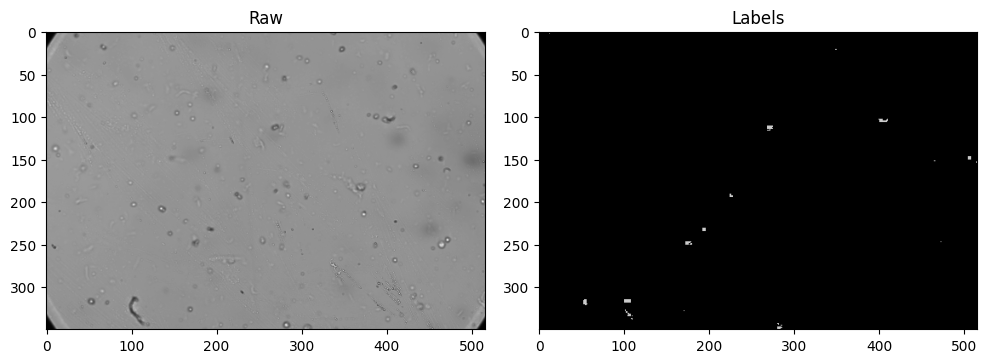

In [ ]:
import matplotlib.pyplot as plt
from rtm.segmentation import SegmentationModel

model = SegmentationModel(MODEL_PATH, fe_use_device="gpu") # If you have a compatible GPU, inference will be much faster if you set fe_use_device="gpu", else ignore the fe_use_device argument

test_img = mic.snap()
test_labels = model.segment(test_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Raw")
axes[1].imshow(test_labels, cmap="nipy_spectral")
axes[1].set_title("Labels")
plt.tight_layout()

## 4. Run the real-time control loop to sort organoids based on size

Start the flow in the chip by setting a flowrate of 0.001 ml/min in the pump that controls the flow rate in the chip (the one connected to the inlet)

In [ ]:
pumpB.start(0.001)

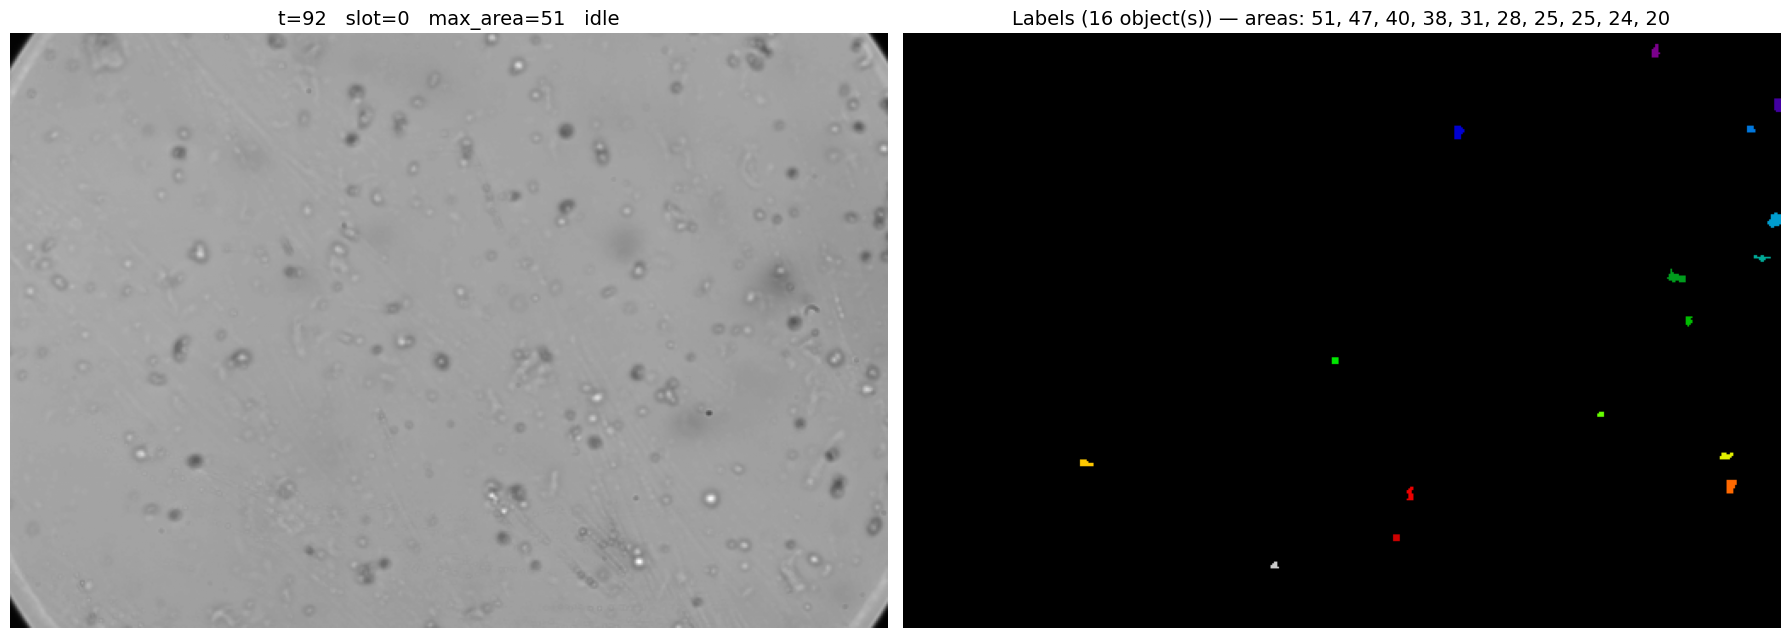

[t=92] max_area=51.0  →  slot 0   (idle)
stopped


In [ ]:
import time
import os
import tifffile
import pandas as pd
from IPython.display import clear_output

from rtm.segmentation import clean_and_label, measure_regions
from rtm.persistence import DetectionLog

# ---- Knobs --------------------------------------------------------------
BIG_AREA_THRESHOLD = 300.0   # any particle with area > this -> slot 1
FRAME_INTERVAL_S = 1         # snap one frame every N seconds
DWELL_FRAMES = 30            # stay at slot 1 this many frames after the last big detection

CLASS_ID = 2
MIN_PIXEL_SIZE = 10
CLOSING_RADIUS = 5


EXPERIMENT_NAME = "exp1"

# ---- State --------------------------------------------------------------
big_log = DetectionLog(f"{STORAGE_PATH}/{EXPERIMENT_NAME}.parquet")
os.makedirs(f"{STORAGE_PATH}/{EXPERIMENT_NAME}", exist_ok=True)

current_slot = 0        # assumes eppendorf is at slot 0 when this cell starts
last_big_frame = None   # frame index of most recent big detection (None = never)

t = 0
try:
    while True:
        img = mic.snap()

        # --- Segment + clean + measure -----------------------------------
        class_labels = model.segment(img)
        cc_labels = clean_and_label(
            class_labels, class_id=CLASS_ID,
            min_pixel_size=MIN_PIXEL_SIZE, closing_radius=CLOSING_RADIUS,
        )
        regions = measure_regions(cc_labels)

        areas = regions["area"].astype(float).tolist() if not regions.empty else []
        max_area = max(areas) if areas else 0.0
        has_big = max_area > BIG_AREA_THRESHOLD

        if has_big:
            last_big_frame = t

        # Stay at slot 1 for DWELL_FRAMES after last big detection
        frames_since_big = (t - last_big_frame) if last_big_frame is not None else None
        in_dwell = frames_since_big is not None and frames_since_big < DWELL_FRAMES
        target_slot = 1 if in_dwell else 0

        # --- Act: only move if the target changed ------------------------
        if target_slot != current_slot:
            eppendorfmover.move_to_slot(target_slot, release_after=True)
            current_slot = target_slot

        # --- Log ---------------------------------------------------------
        big_log.add(pd.DataFrame([{
            "frame": t,
            "timestamp": time.time(),
            "n_objects": len(areas),
            "max_area": max_area,
            "has_big": bool(has_big),
            "frames_since_big": -1 if frames_since_big is None else int(frames_since_big),
            "target_slot": int(target_slot),
            "current_slot": int(current_slot),
        }]))

        # --- Display -----------------------------------------------------
        areas_str = ", ".join(f"{a:.0f}" for a in sorted(areas, reverse=True)[:10]) or "none"
        dwell_str = (
            f"dwell {DWELL_FRAMES - frames_since_big} frames left"
            if in_dwell else "idle"
        )
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(18, 9))
        axes[0].imshow(img, cmap="gray")
        axes[0].set_title(
            f"t={t}   slot={current_slot}   max_area={max_area:.0f}   {dwell_str}",
            fontsize=14,
        )
        axes[1].imshow(cc_labels, cmap="nipy_spectral")
        axes[1].set_title(f"Labels ({len(areas)} object(s)) — areas: {areas_str}", fontsize=14)
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()
        print(f"[t={t}] max_area={max_area:.1f}  →  slot {current_slot}   ({dwell_str})")

        tifffile.imwrite(f"{STORAGE_PATH}/{EXPERIMENT_NAME}/{t:03d}.tiff", img)
        t += 1
        time.sleep(FRAME_INTERVAL_S)
except KeyboardInterrupt:
    print("stopped")


## 5. Inspect the results

You will get two parquet files, one showing if you have a detection in the current frame, and one with the tracks of detected organoids. 
The first one shows one row per frame, with the bounding box of the detected organoid (if any), and the decision taken (0 or 1). The second one shows one row per detected organoid, with its track id, size, and the decision taken for it. You can use these files to analyze the results of the experiment, e.g. to see if the sorting was correct based on the size of the organoids.

In [9]:
import pandas as pd
STORAGE_PATH = "output"
sorts = pd.read_parquet(f"{STORAGE_PATH}/final.parquet")

sorts["timestamp_dt"] = pd.to_datetime(sorts["timestamp"], unit="s")
sorts["elapsed_s"] = sorts["timestamp"] - sorts["timestamp"].iloc[0]
sorts

,frame,timestamp,n_objects,max_area,has_big,frames_since_big,target_slot,current_slot,timestamp_dt,elapsed_s
0,0,1.777053e+09,10,48.0,False,-1,0,0,2026-04-24 17:56:05.494449377,0.000000
1,1,1.777053e+09,8,62.0,False,-1,0,0,2026-04-24 17:56:08.563377380,3.068928
2,2,1.777053e+09,8,37.0,False,-1,0,0,2026-04-24 17:56:11.496788979,6.002340
3,3,1.777053e+09,6,37.0,False,-1,0,0,2026-04-24 17:56:14.443521261,8.949072
4,4,1.777053e+09,5,46.0,False,-1,0,0,2026-04-24 17:56:17.690916300,12.196467
...,...,...,...,...,...,...,...,...,...,...
123,88,1.777054e+09,15,76.0,False,44,0,0,2026-04-24 18:05:13.592406034,548.097957
124,89,1.777054e+09,19,74.0,False,45,0,0,2026-04-24 18:05:16.716719151,551.222270
125,90,1.777054e+09,16,78.0,False,46,0,0,2026-04-24 18:05:20.093519926,554.599071
126,91,1.777054e+09,14,98.0,False,47,0,0,2026-04-24 18:05:23.740497828,558.246048


In [14]:
individual_ones = pd.read_parquet(f"{STORAGE_PATH}/observations.parquet")
individual_ones.sort_values("particle")
individual_ones

,obs_id,frame,x,y,area,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,particle,timestamp
0,0.0,0,358.100000,226.100000,40.0,223.0,356.0,231.0,362.0,0,1.777046e+09
1,1.0,1,358.100000,226.100000,40.0,223.0,356.0,231.0,362.0,0,1.777046e+09
2,0.0,0,358.025641,226.128205,39.0,223.0,356.0,231.0,362.0,0,1.777046e+09
3,1.0,1,358.147059,225.764706,34.0,223.0,356.0,231.0,362.0,0,1.777046e+09
4,2.0,2,358.277778,225.722222,36.0,223.0,356.0,231.0,362.0,0,1.777046e+09
...,...,...,...,...,...,...,...,...,...,...,...
1243,382.0,31,428.541667,203.979167,48.0,201.0,424.0,207.0,434.0,2,1.777052e+09
1244,383.0,31,163.767442,231.720930,43.0,229.0,158.0,235.0,170.0,7,1.777052e+09
1245,384.0,31,123.083333,257.895833,48.0,255.0,120.0,263.0,129.0,8,1.777052e+09
1246,385.0,31,219.272727,266.145455,55.0,263.0,216.0,271.0,225.0,0,1.777052e+09
